# Assignment 1

Throughout this semester I will place great emphasis on determinism as long as the performance hit it sensible. I used to use tensorflow for experiments but upon reading some docs, one can observe that pytorch provides similar deterministic functionalities.

In [1]:
import os
from typing import Sequence

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scoping import scoping
import wandb
from tqdm import tqdm
import time
import pylatex
from torchvision import transforms
from pylatex import Table, Tabular, Tabularx, Center, NoEscape, Document, Package, Figure, NewPage, Command, Label, \
    Marker
from torchviz import make_dot
from tabulate import tabulate

GLOBAL_RANDOM_SEED = 42
# os.environ["PYTHONHASHSEED"] = f"{GLOBAL_RANDOM_SEED}"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
# random.seed(GLOBAL_RANDOM_SEED)
# np.random.seed(GLOBAL_RANDOM_SEED)
# torch.cuda.manual_seed(GLOBAL_RANDOM_SEED)
# torch.cuda.manual_seed_all(GLOBAL_RANDOM_SEED)
# Setting the above is actually antipattern. this is because it discourages resetting PRNG state before drawing random outcomes. which means if a block of code is ran twice, it will draw two different results which e.g. in dataset shuffling is bad.

torch.use_deterministic_algorithms(True)

TORCH_DEVICE = torch.device("cuda")

WAN = False
if WAN:
    wandb.login(key=os.environ['WANDB_TOKEN'])

In [2]:
kgl_ds_path = kagglehub.dataset_download("arashnic/standardized-biomedical-images-medmnist")
!ls {kgl_ds_path}

bloodmnist.npz	 dermamnist.npz		octmnist.npz	  retinamnist_128.npz
breastmnist.npz  medmnistlandscape.png	organmnist3d.npz
chestmnist.npz	 nodulemnist3d.npz	organsmnist.npz


# Aggregating the dataset

Given that the datasets in this repository are pre-split and might not necessarily match our target requirement, I recombine the built-in splits and then draw 3 new splits again. The two functions below facilitate that.

In [3]:
class NormalizedNpzDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        assert x.shape[0] == y.shape[0]  # this wasted 2 hours
        x_scaled = x / 255.0  # raw RGB input (0-255) we do minmax scaling into (0,1)
        self.mean = np.mean(x_scaled, axis=(0, 1, 2), keepdims=True)
        self.std = np.std(x_scaled, axis=(0, 1, 2), keepdims=True)
        print(f'dataset of size {len(x)} images. xshape: {x[0].shape} yshape: {y[0].shape}')
        print(f'rgb mean: {np.squeeze(self.mean, axis=(0, 1, 2))}')
        print(f'std: {np.squeeze(self.std, axis=(0, 1, 2))}')
        x_normal = (x_scaled - self.mean) / (self.std + 1e-8)  # AND then per-channel normalizing
        xnf = torch.from_numpy(x_normal).permute(0, 3, 1, 2).contiguous().float()
        # xnf = torch.from_numpy(x_scaled).permute(0, 3, 1, 2).contiguous().float()
        # contrary to my previous belief, you should NOT push to CUDA here. Instead, you push to GPU in training loop. NOT HERE. store on CPU for now until we need it.
        self.x = xnf
        self.y = torch.from_numpy(y).long().squeeze()

    def denormalize(self, img_tensor):
        img_np = img_tensor.numpy()
        img_denorm = (img_np * self.std) + self.mean
        img_denorm = np.clip(img_denorm, 0, 1)
        return img_denorm

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        lbl = self.y[idx]
        return img, lbl


def viz_dataset(ds, n=16):
    cols = int(n ** 0.5)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols, rows))

    for i in range(n):
        img, lbl = ds[i]
        img = img.permute(1, 2, 0).cpu()  # CHW to HWC
        img_denorm = ds.denormalize(img).squeeze()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_denorm)
        plt.title(f'Label: {lbl}')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Data preparation

Since the splits of the provided dataset are different sizes than the requested sizes, we have to recombine and re-split. Again, for determinism we reset prngs before "drawing" random ops.

The BS parameter is the global batch size. $BS = 1$ would simulate SGD, which would perform horribly on this dataset because of how noisy the updates would become. $BS = x>len(TrainDS)$ would simulate Full-batch gradient descent. Values in between those two would be Mini-batch GD and a trade-off between these two scenarios:
- Small BS: Closer to SGD, noisy updates, lower memory consumption, slower convergence
- Larger BS: Closer to Full GD, smooth updates, higher memory consumption, faster convergence

In [4]:
npdata = np.load(f"{kgl_ds_path}/bloodmnist.npz")
print(list(npdata))  # keys
npx = np.concatenate([npdata[k] for k in ['train_images', 'val_images', 'test_images']], axis=0)
npy = np.concatenate([npdata[k] for k in ['train_labels', 'val_labels', 'test_labels']], axis=0)
np.random.seed(GLOBAL_RANDOM_SEED)  # reset prng state if this is to ever run twice
shuffle_mask = np.random.permutation(len(npx))
npx, npy = npx[shuffle_mask], npy[shuffle_mask]

classes_no = len(np.unique(npy))
print(f'classes_no: {classes_no}')
print(f'total_dataset_size: {len(npx)}')

train_idx, val_idx = int(0.7 * len(npx)), int(0.85 * len(npx))  # 70 train - 15 val- 15 test
train_x, val_x, test_x = npx[:train_idx], npx[train_idx:val_idx], npx[val_idx:]
train_y, val_y, test_y = npy[:train_idx], npy[train_idx:val_idx], npy[val_idx:]


['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']
classes_no: 8
total_dataset_size: 17092


In [5]:
def train_step(model: torch.nn.Module, optimizer: torch.optim.Optimizer, loss_func, images, labels):
    model.train()
    images, labels = images.to(TORCH_DEVICE, non_blocking=True), labels.to(TORCH_DEVICE, non_blocking=True)
    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_func(outputs, labels)  # scalar
    loss.backward()
    optimizer.step()
    correct = (outputs.argmax(dim=1) == labels).sum().item()
    return loss.item(), correct, images.size(0)


@torch.no_grad()
def val_step(model: torch.nn.Module, loss_func, images, labels):
    model.eval()
    images, labels = images.to(TORCH_DEVICE, non_blocking=True), labels.to(TORCH_DEVICE, non_blocking=True)
    outputs = model(images)
    loss = loss_func(outputs, labels)  # scalar
    correct = (outputs.argmax(dim=1) == labels).sum().item()
    return loss.item(), correct, images.size(0)


def epoch_train(dataloader, model: nn.Module, optimizer: torch.optim.Optimizer, loss_func: nn.functional, idx: int):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    pbar = tqdm(dataloader, desc=f'[TRN:{idx}]', unit="batch", leave=True)
    for images, labels in pbar:
        loss_val, correct, bs = train_step(model, optimizer, loss_func, images, labels)
        total_loss += loss_val * bs
        total_correct += correct
        total_samples += bs
        pbar.set_postfix(loss=f"{loss_val:.4f}", acc=f"{(correct / bs) * 100:.2f}%")
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    # print(f"[TRN:{idx}] Loss: {avg_loss:.4f}, Acc: {avg_acc*100:.2f}%")
    return avg_loss, avg_acc


def epoch_val(dataloader, model: nn.Module, loss_func: nn.functional, idx: int):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    pbar = tqdm(dataloader, desc=f'[VAL:{idx}]', unit="batch", leave=True)
    for images, labels in pbar:
        loss_val, correct, bs = val_step(model, loss_func, images, labels)
        total_loss += loss_val * bs
        total_correct += correct
        total_samples += bs
        pbar.set_postfix(loss=f"{total_loss / total_samples:.4f}", acc=f"{(total_correct / total_samples) * 100:.2f}%")
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    # print(f"[VAL:{idx}] Loss: {avg_loss:.4f}, Acc: {avg_acc*100:.2f}%")
    return avg_loss, avg_acc



def exp_snippet(df, title:str, label :str):
    t = Table(position="H")
    t.append(NoEscape(r'\centering'))
    tb = Tabular('|cc|')
    tb.add_hline()
    tb.add_row(list(df.columns))
    tb.add_hline()
    for row in df.index:
         tb.add_row(list(df.loc[row, :]))
    tb.add_hline()

    t.append(tb)
    t.add_caption(title)
    t.append(Label(Marker(label)))

    return t.dumps()


def fmt_cell(x):
    s = str(x)
    s = pylatex.escape_latex(s)
    return NoEscape(r"\makecell{" + s + "}")

def comparison_snippet(df, title:str,label:str):
    t = Table(position="H")
    ncols = len(df.columns) + 1
    tb = Tabular(NoEscape(r'|*{' + str(ncols) + '}{c}|'),width=ncols)
    tb.add_hline()
    header = ["Exp. ID"] + list(df.columns)
    tb.add_row([fmt_cell(h) for h in header])
    tb.add_hline()
    for row in df.index:
        row_cells = [row] + list(df.loc[row, :])
        tb.add_row([fmt_cell(c) for c in row_cells])
        tb.add_hline()

    t.append(NoEscape(
        f'\\begin{{adjustbox}}{{width=1.4\\textwidth,center}}\n{tb.dumps().replace(r"\newline", r"\\")}\n\\end{{adjustbox}}'
    ))
    t.add_caption(title)
    t.append(Label(Marker(label)))
    return t.dumps()



def figure_snippet(fig_path: str, title: str, label: str, width: str = "1\\textwidth"):
    fig = Figure(position="H")
    fig.add_image(fig_path, width=NoEscape(width))
    fig.add_caption(title)
    fig.append(Label(Marker(label)))

    return fig.dumps()

In [6]:
EPOCHS_TO_TRAIN = 100
default_LR = 1e-3
default_activation = nn.ReLU()

experiment_repository = {}  #keyed by id hopefully


def run_experiment(id: str, title: str,
                   tdl: torch.utils.data.DataLoader,
                   vdl: torch.utils.data.DataLoader,
                   model: nn.Module,
                   optimizer: torch.optim.Optimizer,
                   loss_func: nn.functional,
                   scheduler: torch.optim.lr_scheduler, extrainfo: dict):
    torch.manual_seed(
        GLOBAL_RANDOM_SEED)  # dropout determinism needs this. I want these experiments to be fully deterministic
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    model = model.to(TORCH_DEVICE)
    training_time_s = float(0)
    for epoch in range(EPOCHS_TO_TRAIN):
        t0 = time.time()
        train_loss, train_acc = epoch_train(tdl, model, optimizer, loss_func, epoch)
        t1 = time.time()
        training_time_s += t1 - t0
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_loss, val_acc = epoch_val(vdl, model, loss_func, epoch)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if scheduler:
            scheduler.step()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plt.suptitle(f"Experiment {id}")

    axes[0].plot(range(EPOCHS_TO_TRAIN), train_losses, label="Train Loss")
    axes[0].plot(range(EPOCHS_TO_TRAIN), val_losses, label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(range(EPOCHS_TO_TRAIN), train_accs, label="Train Acc")
    axes[1].plot(range(EPOCHS_TO_TRAIN), val_accs, label="Val Acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    fig_path = f"figures/{id}.png"
    plt.savefig(fig_path)
    plt.show()

    summary = {
        "Val Acc": f'{val_accs[-1] * 100:.2f}%',
        "Val Loss": round(val_losses[-1], 2),
        "Train Acc": f'{train_accs[-1] * 100:.2f}%',
        "Train Loss": round(train_losses[-1], 2),
        "Batch Size": BS,
        "Train Time (sec.)": round(training_time_s, 2),
        "Activation": default_activation.__class__.__name__,
        "Training Samples": len(tdl.dataset),
        "Scheduler" : "None",
        "Param Count": sum(p.numel() for p in model.parameters()),
        "Optimizer": optimizer.__class__.__name__,
        "Optimizer Params" :f'LR={default_LR}',
        "Regularization" : "None",
        "Loss": loss_func.__name__ if hasattr(loss_func, "__name__") else str(loss_func),
        # "Scheduler": str(scheduler.__class__.__name__) if scheduler else "None",
    }

    summary.update(extrainfo)
    sorted_dict = dict(sorted(summary.items(), key=lambda x: x[0].lower()))
    experiment_repository[id] = sorted_dict

    col_df = pd.DataFrame(list(experiment_repository[id].items()), columns=["Metric", "Value"])
    col_df.index = range(len(col_df))
    display(col_df)
    dfl = exp_snippet(col_df, title=f'{title} Experiment Parameters', label=f'{id}_params')
    fgl = figure_snippet(fig_path, title=f'{title} Accuracy/Loss plot', label=f'{id}_graph')

    with open(f'figures/{id}.tex', 'w') as f:
        f.write(fgl)
        f.write("\n\n")
        f.write(dfl)

    return


dataset of size 11964 images. xshape: (28, 28, 3) yshape: (1,)
rgb mean: [0.79452739 0.66003965 0.69646342]
std: [0.21550978 0.24141456 0.11776031]
dataset of size 2564 images. xshape: (28, 28, 3) yshape: (1,)
rgb mean: [0.79453971 0.65949866 0.69585228]
std: [0.2152302  0.24129205 0.11800309]
dataset of size 2564 images. xshape: (28, 28, 3) yshape: (1,)
rgb mean: [0.79296784 0.65775895 0.69511233]
std: [0.21607412 0.24234762 0.11840363]


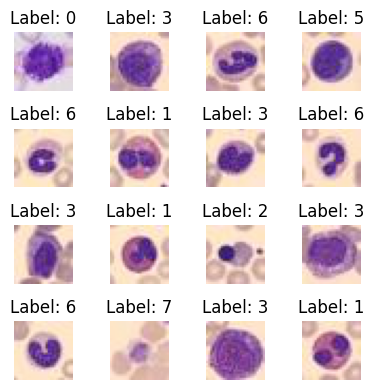

In [7]:
BS = 256
train_ds = NormalizedNpzDataset(train_x, train_y)
val_ds = NormalizedNpzDataset(val_x, val_y)
test_ds = NormalizedNpzDataset(test_x, test_y)

train_dl = torch.utils.data.DataLoader(train_ds, batch_size=BS)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=BS)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=BS)

train_dl_64 = torch.utils.data.DataLoader(train_ds, batch_size=64)

viz_dataset(train_dl.dataset)

# Part 2 - Basic MLP

[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 348.64batch/s, acc=84.05%, loss=1.2325]


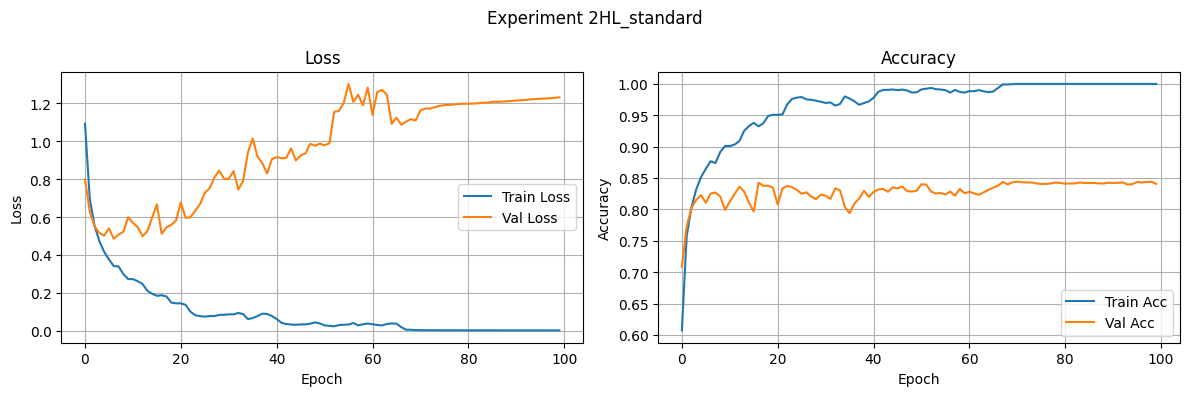

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.98%
9,Train Loss,0.0


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 294.90batch/s, acc=82.88%, loss=1.6087]


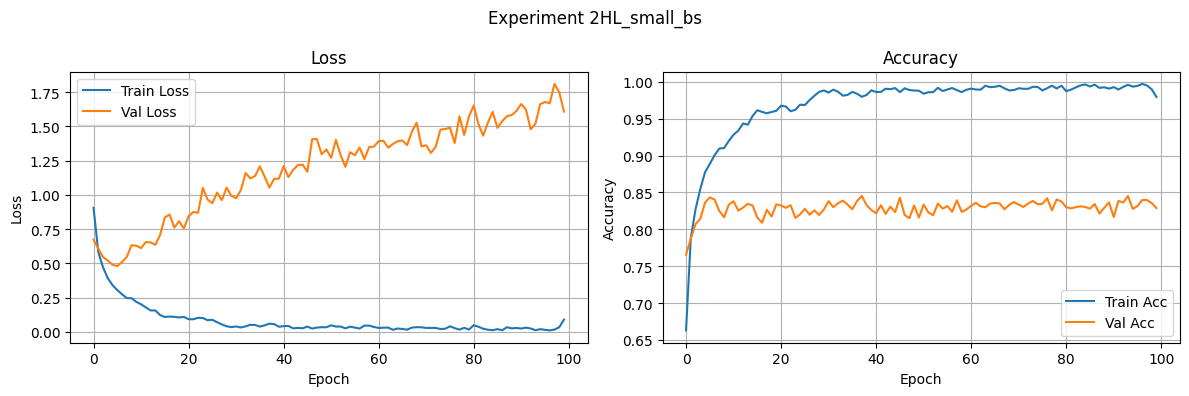

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,97.94%
9,Train Loss,0.09


In [8]:
celoss = nn.CrossEntropyLoss()


# this model is going to be used in Part 2 and some portions of Part 3, 4 and even 5 so we might as well abstract it.
def create_basic_mlp(activation):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28 * 3, 128),
        activation(),
        nn.Linear(128, 64),
        activation(),
        nn.Linear(64, 10)
    )


with scoping():
    model = create_basic_mlp(nn.ReLU)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "2HL_standard", "2HL MLP + ReLU",
        train_dl, val_dl,
        model, optim, celoss, None,
        {}
    )

with scoping():
    model = create_basic_mlp(nn.ReLU)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "2HL_small_bs", "2HL MLP + ReLU BS=64",
        train_dl_64, val_dl,
        model, optim, celoss, None,
        {}
    )


# Activation Experiments

[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 313.34batch/s, acc=84.87%, loss=1.1520]


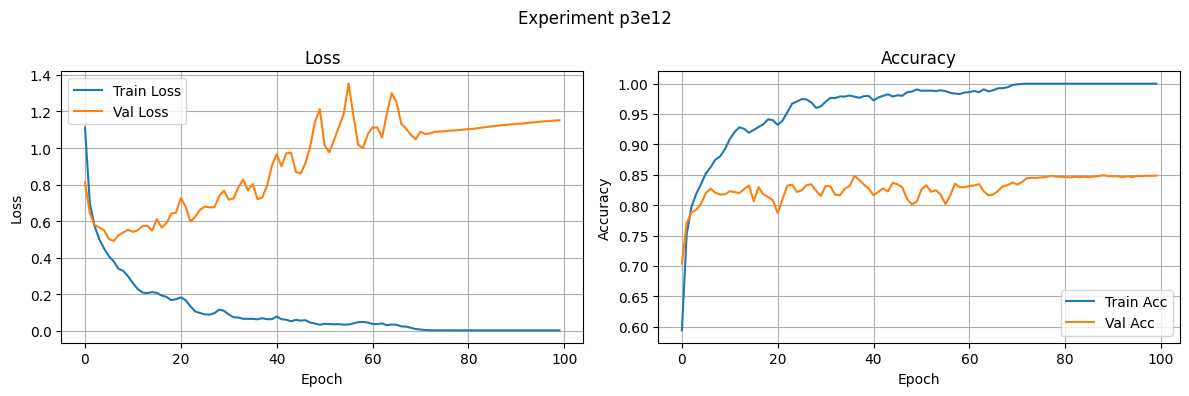

,Metric,Value
0,Activation,LeakyReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.98%
9,Train Loss,0.0


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 269.82batch/s, acc=82.37%, loss=0.9154]


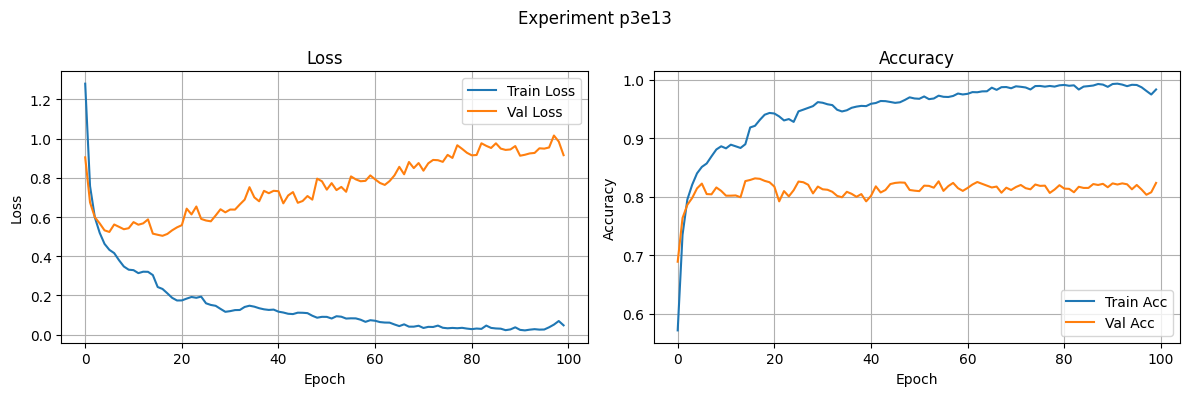

,Metric,Value
0,Activation,Tanh
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,98.37%
9,Train Loss,0.05


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 214.18batch/s, acc=83.62%, loss=0.7177]


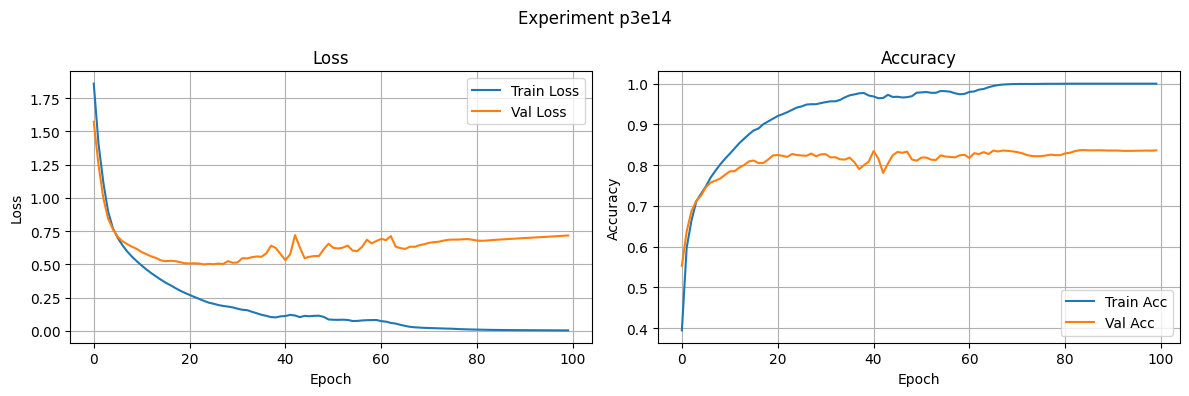

,Metric,Value
0,Activation,Sigmoid
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.97%
9,Train Loss,0.0


In [9]:
# relu version is just the standard 2HL MLP


with scoping():
    model = create_basic_mlp(nn.LeakyReLU)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "p3e12",
        "LeakyReLU Activation",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
            "Activation": "LeakyReLU",
        }
    )

with scoping():
    model = create_basic_mlp(nn.Tanh)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "p3e13",
        "Tanh Activations",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
            "Activation": "Tanh",
        }
    )

with scoping():
    model = create_basic_mlp(nn.Sigmoid)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "p3e14",
        "Sigmoid Activation",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
            "Activation": "Sigmoid",
        }
    )

# Optimizers Experiments

[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 258.43batch/s, acc=71.68%, loss=0.8126]


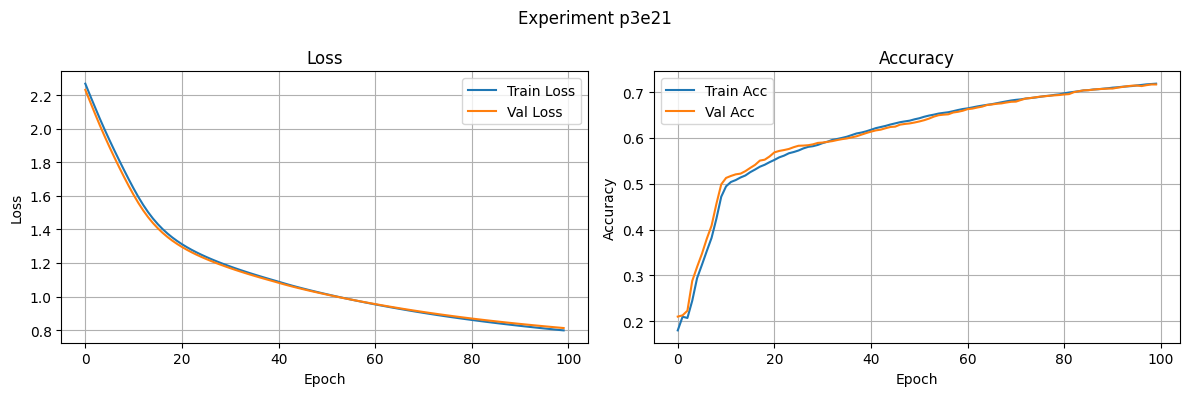

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,SGD
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,71.86%
9,Train Loss,0.8


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 266.55batch/s, acc=85.69%, loss=0.4276]


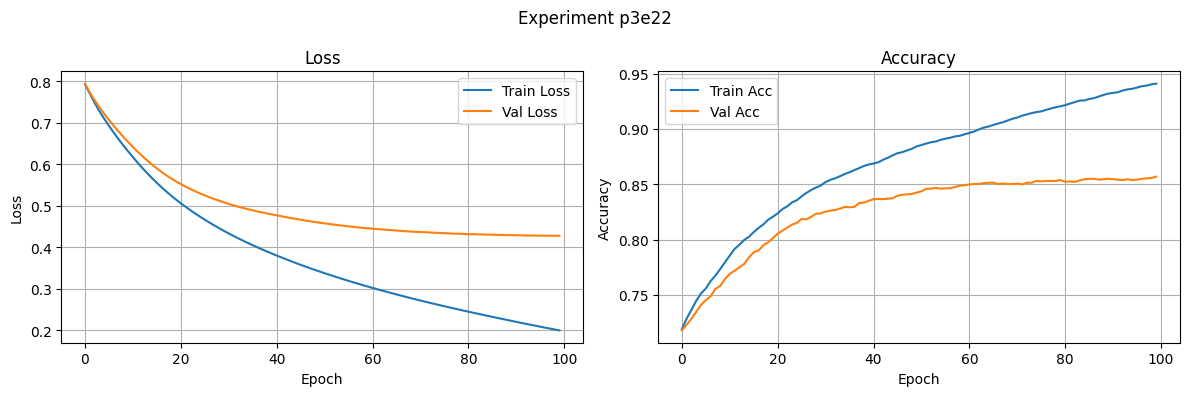

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,SGD
4,Optimizer Params,LR=0.001 \nmomentum=0.9
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,94.08%
9,Train Loss,0.2


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 269.69batch/s, acc=84.17%, loss=1.1979]


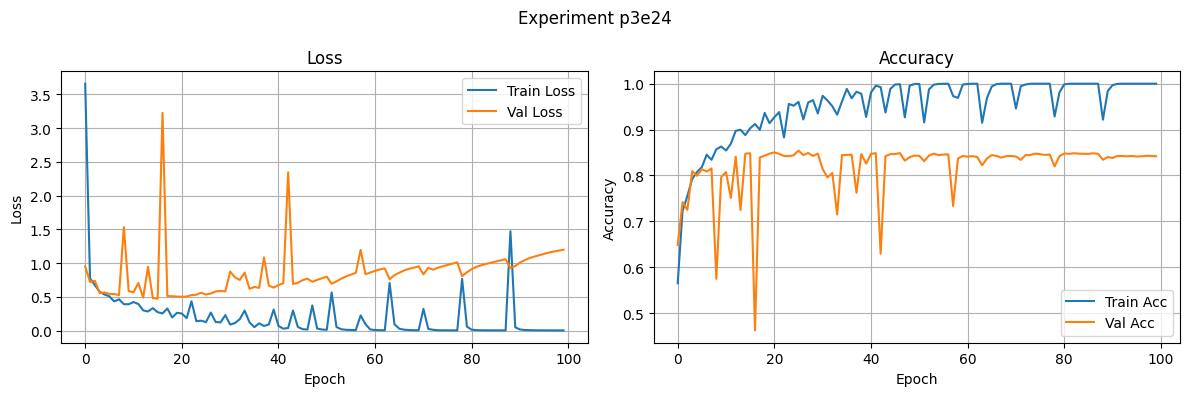

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,RMSprop
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.98%
9,Train Loss,0.0


In [10]:
celoss = nn.CrossEntropyLoss()
# we use the task 2 model as the baseline and just change the optimisers
model = create_basic_mlp(nn.ReLU)
with scoping():
    optim = torch.optim.SGD(model.parameters(), lr=default_LR)
    run_experiment(
        "p3e21",
        "SGD",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
        }
    )

with scoping():
    optim = torch.optim.SGD(model.parameters(), lr=default_LR, momentum=0.9)
    run_experiment(
        "p3e22",
        "SGD momentum",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
            "Optimizer Params": f'LR={default_LR} \nmomentum=0.9',
        }
    )

# p3e23 adam is the standard 2HL

with scoping():
    optim = torch.optim.RMSprop(model.parameters(), lr=default_LR)
    run_experiment(
        "p3e24",
        "RMSprop",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
        }
    )


# Depth Experiments


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 280.11batch/s, acc=82.57%, loss=1.0659]


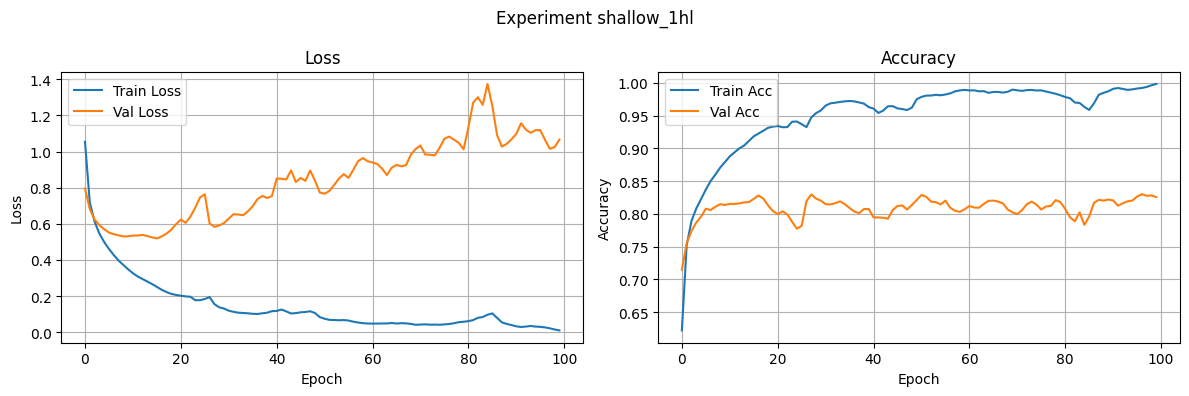

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,151242
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.84%
9,Train Loss,0.01


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 263.67batch/s, acc=85.10%, loss=1.1700]


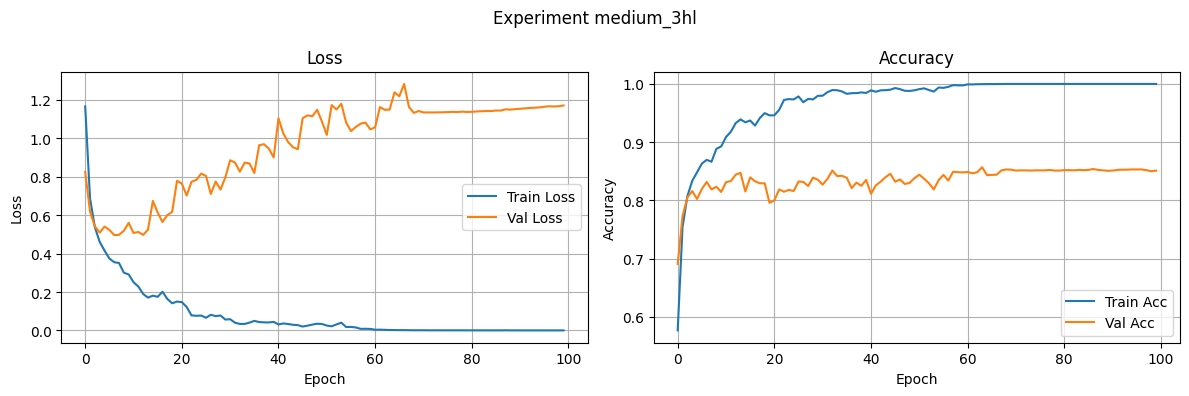

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,644170
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.98%
9,Train Loss,0.0


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 284.20batch/s, acc=83.70%, loss=1.1032]


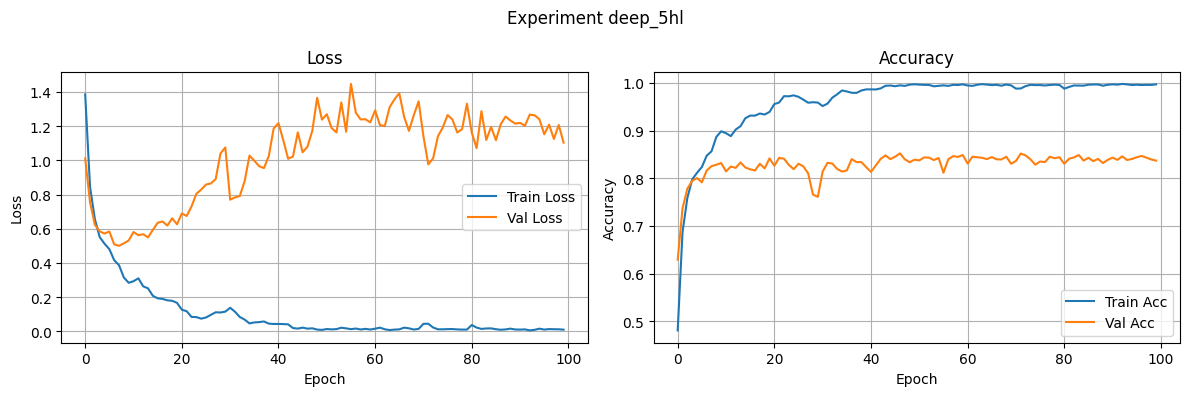

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,1379626
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.68%
9,Train Loss,0.01


In [11]:
celoss = nn.CrossEntropyLoss()

with scoping():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28 * 3, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "shallow_1hl",
        "Shallow 1HL (64)",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
        }
    )

with scoping():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28 * 3, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "medium_3hl",
        "Medium 3HL (256,128,64)",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
        }
    )

with scoping():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28 * 3, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 10)
    )
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "deep_5hl",
        "Deep 5HL (512,256,128,64,32)",
        train_dl, val_dl,
        model, optim, celoss, None,
        {
        }
    )


# Regularization experiments

[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 357.04batch/s, acc=85.34%, loss=0.7594]


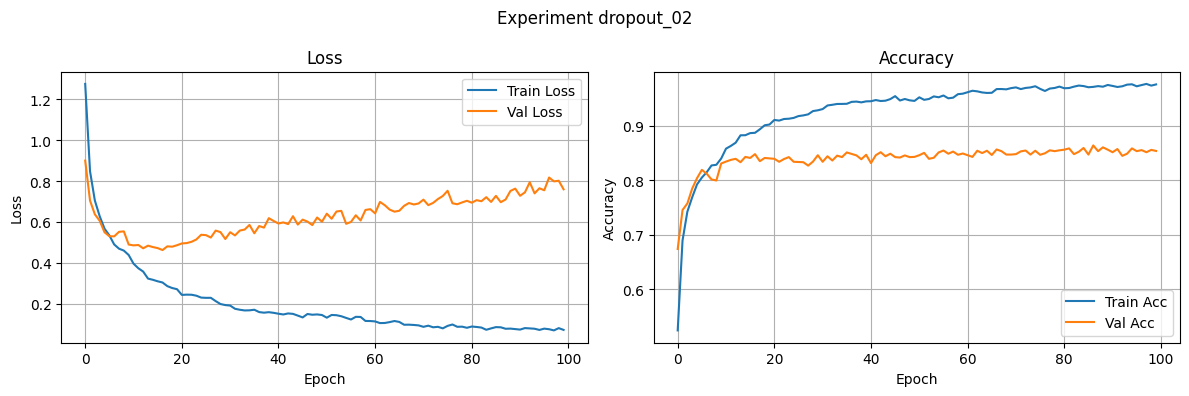

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,Dropout 0.2
7,Scheduler,None
8,Train Acc,97.54%
9,Train Loss,0.07


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 285.66batch/s, acc=83.97%, loss=0.5725]


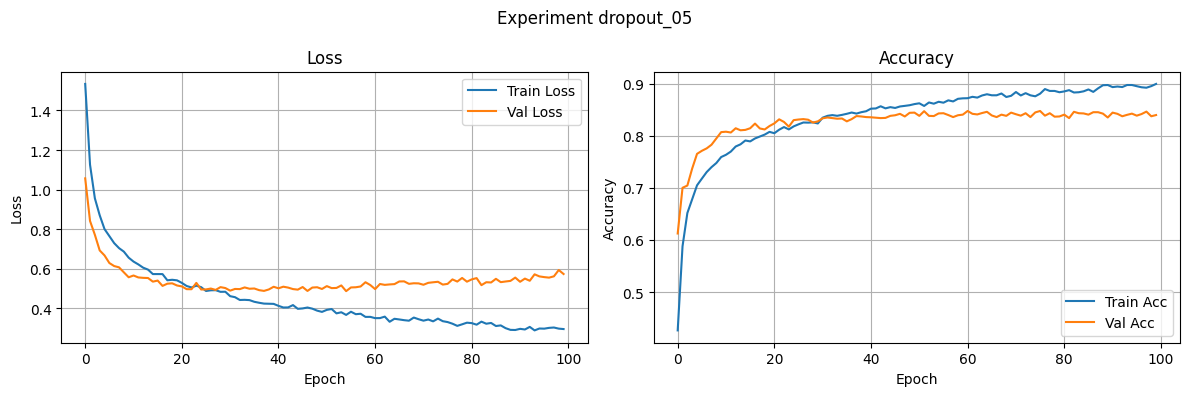

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,Dropout 0.5
7,Scheduler,None
8,Train Acc,89.94%
9,Train Loss,0.29


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 228.99batch/s, acc=84.75%, loss=0.9268]


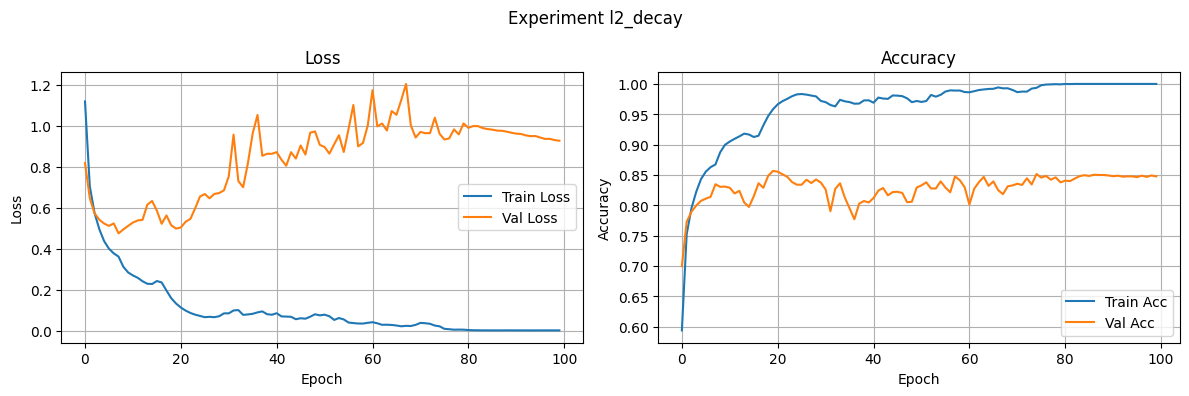

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,L2 WD 1e-4
7,Scheduler,None
8,Train Acc,99.98%
9,Train Loss,0.0


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 270.64batch/s, acc=86.35%, loss=0.7335]


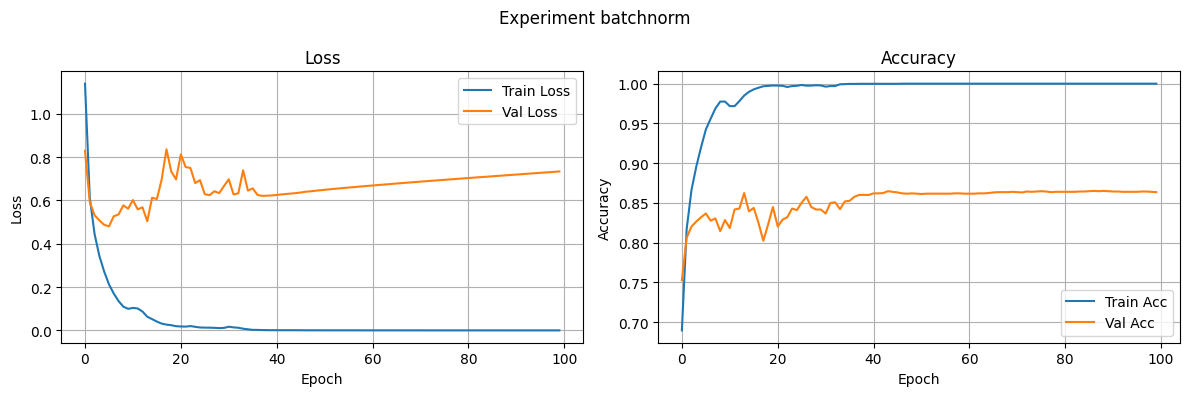

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310474
6,Regularization,BatchNorm
7,Scheduler,None
8,Train Acc,100.00%
9,Train Loss,0.0


In [12]:
celoss = nn.CrossEntropyLoss()

with scoping():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28 * 3, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 10)
    )
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "dropout_02",
        "2HL MLP + 0.2 dropouts",
        train_dl, val_dl,
        model, optim, celoss, None,
        { "Regularization": "Dropout 0.2"}
    )

with scoping():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28 * 3, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 10)
    )
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "dropout_05",
        "+2HL MLP + 0.5 dropouts",
        train_dl, val_dl,
        model, optim, celoss, None,
        {"Regularization": "Dropout 0.5"}
    )

with scoping():
    model = create_basic_mlp(nn.ReLU)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR, weight_decay=1e-4)
    run_experiment(
        "l2_decay",
        "2HL MLP + 1e-4 L2 Weight Decay",
        train_dl, val_dl,
        model, optim, celoss, None,
        {"Regularization": "L2 WD 1e-4"}
    )

with scoping():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28 * 3, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    run_experiment(
        "batchnorm",
        "2HL MLP + Batch normalization",
        train_dl, val_dl,
        model, optim, celoss, None,
        {"Regularization": "BatchNorm"}
    )




# Scheduling Experiments

[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 254.44batch/s, acc=85.18%, loss=0.4550]


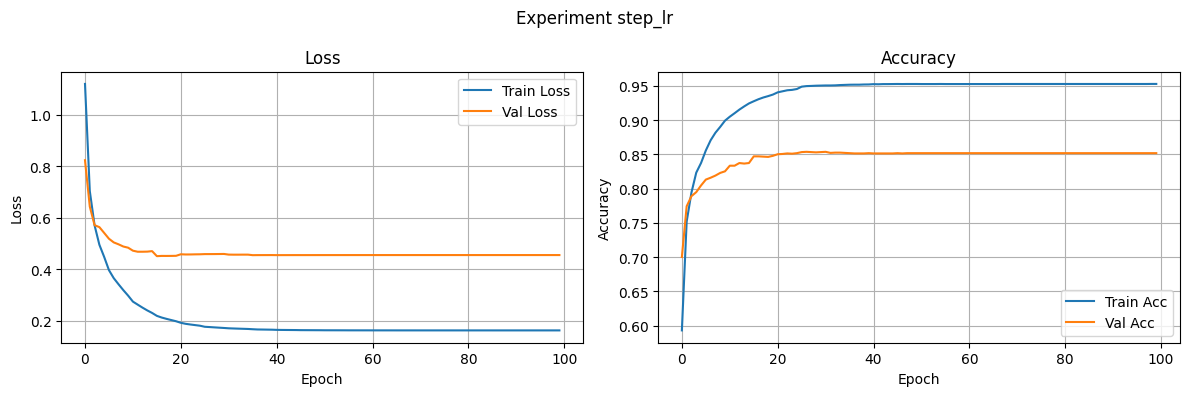

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,StepLR \nstep=5 \ngamma=0.5
8,Train Acc,95.29%
9,Train Loss,0.16


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 333.29batch/s, acc=83.78%, loss=0.9707]


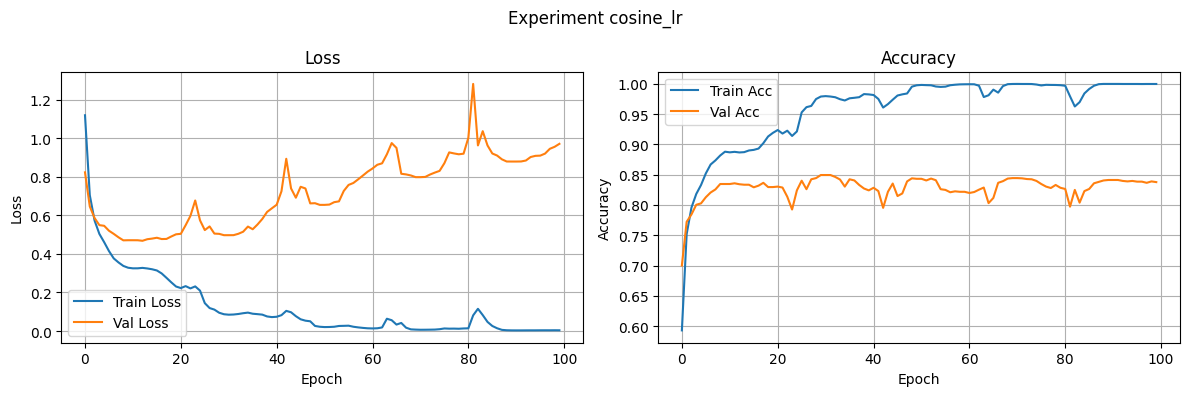

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,CosineAnnealingLR \nT_max=10
8,Train Acc,99.98%
9,Train Loss,0.0


In [13]:
import torch.optim.lr_scheduler as lr_sched

celoss = nn.CrossEntropyLoss()

with scoping():
    model = create_basic_mlp(nn.ReLU)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    scheduler = lr_sched.StepLR(optim, step_size=5, gamma=0.5)
    run_experiment(
        "step_lr",
        "2HL MLP + StepLR",
        train_dl, val_dl,
        model, optim, celoss, scheduler,
        {"Scheduler": "StepLR \nstep=5 \ngamma=0.5"}
    )

with scoping():
    model = create_basic_mlp(nn.ReLU)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)
    scheduler = lr_sched.CosineAnnealingLR(optim, T_max=10)
    run_experiment(
        "cosine_lr",
        "2HL MLP + CosineAnnealingLR",
        train_dl, val_dl,
        model, optim, celoss, scheduler,
        {"Scheduler": "CosineAnnealingLR \nT_max=10"}
    )


# Alternative loss functions

[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 282.62batch/s, acc=84.32%, loss=0.0248]


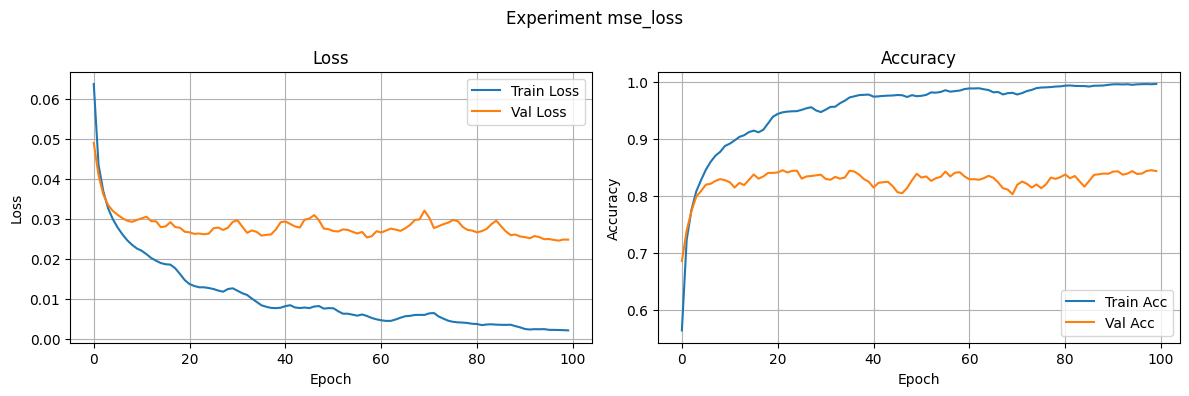

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,mse_wrapper
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.63%
9,Train Loss,0.0


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 243.60batch/s, acc=83.54%, loss=1.1899]


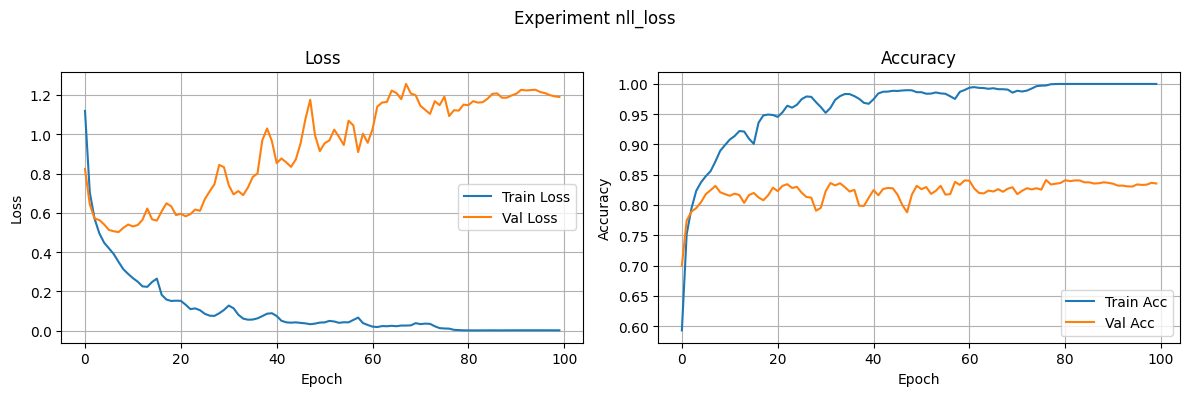

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,nll_wrapper
3,Optimizer,Adam
4,Optimizer Params,LR=0.001
5,Param Count,310090
6,Regularization,None
7,Scheduler,None
8,Train Acc,99.98%
9,Train Loss,0.0


In [14]:
mseloss = nn.MSELoss()

def one_hot(t, num_classes=10):
    return nn.functional.one_hot(t, num_classes=num_classes).float()

with scoping():
    model = create_basic_mlp(nn.ReLU)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)

    def mse_wrapper(pred, target):
        target_oh = one_hot(target, 10)
        return mseloss(pred, target_oh)

    run_experiment(
        "mse_loss",
        "2HL MLP + MSELoss (one-hot targets)",
        train_dl, val_dl,
        model, optim, mse_wrapper, None,
        {}
    )

nllloss = nn.NLLLoss()

def nll_wrapper(pred, target):
    pred = nn.functional.log_softmax(pred, dim=1)
    return nllloss(pred, target)

with scoping():
    model = create_basic_mlp(nn.ReLU)
    optim = torch.optim.Adam(model.parameters(), lr=default_LR)

    run_experiment(
        "nll_loss",
        "2HL MLP + NLLLoss (wrapped)",
        train_dl, val_dl,
        model, optim, nll_wrapper, None,
        {}
    )


[VAL:99]: 100%|██████████| 11/11 [00:00<00:00, 299.16batch/s, acc=86.47%, loss=0.5086]


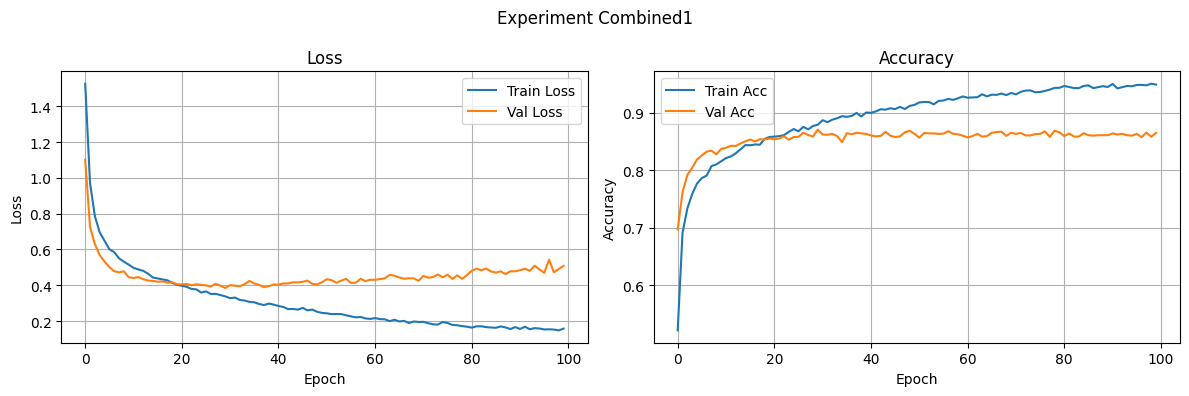

,Metric,Value
0,Activation,ReLU
1,Batch Size,256
2,Loss,CrossEntropyLoss()
3,Optimizer,AdamW
4,Optimizer Params,LR=0.001
5,Param Count,310474
6,Regularization,Dropout 0.5 \nBatchNorm \n1e-3 Weight Decay
7,Scheduler,None
8,Train Acc,94.87%
9,Train Loss,0.16


In [15]:
with scoping():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28 * 3, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 10)
    )
    optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)
    run_experiment(
        "Combined1",
        "+2HL + 0.5 dropouts + BN + WD",
        train_dl, val_dl,
        model, optim, celoss, None,
        {"Regularization": "Dropout 0.5 \nBatchNorm \n1e-3 Weight Decay"}
    )

# Comparing everything

In [16]:
all_experiments_df = pd.DataFrame.from_dict(experiment_repository, orient='index')
all_experiments_df = all_experiments_df.reindex(sorted(all_experiments_df.columns), axis=1)
all_experiments_df = all_experiments_df.drop(
    columns=["Batch Size", "Training Samples", "Loss"], errors="ignore")
all_experiments_df =  all_experiments_df.sort_values("Val Acc", ascending=False)
display(all_experiments_df)
fc = comparison_snippet(all_experiments_df, "The ultimate comparison", "allcomp")
with open("fullcomp.tex", 'w') as f:
    f.write(fc)


,Activation,Optimizer,Optimizer Params,Param Count,Regularization,Scheduler,Train Acc,Train Loss,Train Time (sec.),Val Acc,Val Loss
Combined1,ReLU,AdamW,LR=0.001,310474,Dropout 0.5 \nBatchNorm \n1e-3 Weight Decay,None,94.87%,0.16,29.46,86.47%,0.51
batchnorm,ReLU,Adam,LR=0.001,310474,BatchNorm,None,100.00%,0.00,36.18,86.35%,0.73
p3e22,ReLU,SGD,LR=0.001 \nmomentum=0.9,310090,None,None,94.08%,0.20,27.07,85.69%,0.43
dropout_02,ReLU,Adam,LR=0.001,310090,Dropout 0.2,None,97.54%,0.07,21.40,85.34%,0.76
step_lr,ReLU,Adam,LR=0.001,310090,None,StepLR \nstep=5 \ngamma=0.5,95.29%,0.16,23.33,85.18%,0.46
medium_3hl,ReLU,Adam,LR=0.001,644170,None,None,99.98%,0.00,23.71,85.10%,1.17
p3e12,LeakyReLU,Adam,LR=0.001,310090,None,None,99.98%,0.00,20.57,84.87%,1.15
l2_decay,ReLU,Adam,LR=0.001,310090,L2 WD 1e-4,None,99.98%,0.00,30.32,84.75%,0.93
mse_loss,ReLU,Adam,LR=0.001,310090,None,None,99.63%,0.00,24.61,84.32%,0.02
p3e24,ReLU,RMSprop,LR=0.001,310090,None,None,99.98%,0.00,23.67,84.17%,1.20
